# NVIDIA Stock Analysis
### Comparative Evaluation of Eight Predictive Models for NVIDIA Stock Price Forecasting

---

## Overview

This project investigates the effectiveness of multiple predictive models for estimating the price of NVIDIA (NVDA) stock using historical market data and external economic indicators.

The objective was to evaluate how different combinations of explanatory variables influence prediction accuracy while verifying that each model satisfies the assumptions required for ordinary least squares (OLS) linear regression.

Originally developed as my International Baccalaureate (IB) Extended Essay, this repository contains the complete analysis, source code, and supporting documentation.

---

## Objectives

- Collect historical financial and economic data from multiple public sources.
- Develop and compare eight predictive linear regression models.
- Evaluate each model using statistical diagnostics.
- Compare the predictive performance of each model.
- Identify the strengths and limitations of OLS regression for financial forecasting.

---

## Data Sources

The analysis uses publicly available datasets from:

- **Yahoo Finance** (via `yfinance`)
  - NVIDIA historical stock prices
  - Technology sector stocks
  - ETFs
  - Futures contracts
  - Market indices

- **U.S. Geological Survey (USGS)**
  - Historical U.S. metal production statistics

---

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Statsmodels
- SciPy
- yfinance

---

## Notebook Structure

1. **Data Collection & Preprocessing**
2. **Helper Functions**
3. **Model 1 – Technology Sector Ecosystem**
   - Evaluates the predictive power of NVIDIA's suppliers, partners, and major customers.
4. **Model 2 – U.S. Metal Production**
   - Investigates whether domestic metal production correlates with NVIDIA's stock performance.
5. **Model 3 – Metal Futures**
   - Examines the influence of commodity futures prices on NVIDIA's valuation.
6. **Model 4 – Metal Exchange-Traded Funds (ETFs)**
   - Evaluates whether commodity-focused ETFs provide stronger predictive signals than individual futures contracts.
7. **Model 5 – S&P 500 Index**
   - Uses the broader U.S. equity market as a predictor of NVIDIA's stock price.
8. **Model 6 – NASDAQ-100 Index**
   - Evaluates the predictive relationship between NVIDIA and the technology-heavy NASDAQ-100 index.
9. **Model 7 – AI Infrastructure Energy Sector (SMR & MMR Companies)**
   - Investigates whether companies involved in small and micro modular reactor technologies exhibit predictive relationships with NVIDIA, given the increasing energy demands of AI infrastructure.
10. **Composite Model – Synthesis of Optimal Predictors**
    - Combines the strongest variables identified across all previous models into a final regression model.
11. **Model Comparison & Statistical Evaluation**
12. **Conclusions**

---

## Methodology

Each model follows the same general workflow:

1. Collect historical data.
2. Clean and preprocess the dataset.
3. Construct a multiple linear regression model.
4. Evaluate statistical assumptions, including:
   - Multicollinearity (Variance Inflation Factor)
   - Homoscedasticity (Breusch–Pagan Test)
   - Normality of residuals
   - Independence of residuals (Durbin–Watson Test)
5. Compare performance metrics across all models.

---

## Disclaimer

This project was developed for educational and research purposes. It is not intended to provide financial or investment advice.


In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import yfinance as yf
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import norm


## Functions 

In [19]:
def Pagan_test(data): 
    # Create DataFrame from data dictionary
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df=data

    # Drop rows with missing values to avoid errors during modeling
    df = df.dropna()

    # Build the formula string dynamically from your independent variables
    independent_vars = "+".join([f"X{i}" for i in range(1, len(df.columns))])
    formula = f"Y ~ {independent_vars}"

    # Fit the OLS regression model
    model = smf.ols(formula=formula, data=df).fit()

    # Run the Breusch-Pagan test
    bp_test = sms.het_breuschpagan(model.resid, model.model.exog)
    labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']

    # Print Breusch-Pagan test results
    for label, value in zip(labels, bp_test):
        print(f"{label}: {value}")

def Durbin_Watson_test(data, one_x=False):
    # Create DataFrame from data dictionary
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else:
        df = data

    # Drop rows with missing values to avoid errors during modeling
    df = df.dropna()

    # Build the formula string dynamically from your independent variables
    if not one_x: 
        independent_vars = "+".join([f"X{i}" for i in range(1, len(df.columns))])
        formula = f"Y ~ {independent_vars}"
    else:
        formula = "Y ~ X1"
    # Fit the OLS regression model
    model = smf.ols(formula=formula, data=df).fit()

    # Compute Durbin-Watson statistic
    dw_stat = durbin_watson(model.resid)

    # Approximate p-value using normal approximation on rho_hat
    n = len(model.resid)
    k = len(df.columns) - 1
    rho_hat = 1 - dw_stat / 2
    z_stat = rho_hat / np.sqrt(1 / (n - k))
    p_value = 2 * (1 - norm.cdf(abs(z_stat)))

    labels = ['Durbin-Watson statistic', 'rho estimate', 'z-statistic', 'p-value']
    values = [dw_stat, rho_hat, z_stat, p_value]

    # Print Durbin-Watson test results
    for label, value in zip(labels, values):
        print(f"{label}: {value}")

def Cochrane_Orcutt_test(data):
    # Create DataFrame from data dictionary
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else:
        df = data

    # Drop rows with missing values
    df = df.dropna()

    # Build formula dynamically
    independent_vars = "+".join([f"X{i}" for i in range(1, len(df.columns))])
    formula = f"Y ~ {independent_vars}"

    # Step 1: Fit initial OLS model
    model = smf.ols(formula=formula, data=df).fit()

    # Step 2: Estimate rho from residuals
    residuals = model.resid
    rho = np.corrcoef(residuals[:-1], residuals[1:])[0, 1]

    # Step 3: Transform variables using rho
    df_transformed = df.copy()
    for col in df.columns:
        df_transformed[col] = df[col] - rho * df[col].shift(1)
    df_transformed = df_transformed.dropna()

    # Step 4: Refit OLS on transformed data
    model_co = smf.ols(formula=formula, data=df_transformed).fit()

    # Step 5: Compute DW on new residuals
    dw_stat = durbin_watson(model_co.resid)
    n = len(model_co.resid)
    k = len(df.columns) - 1
    rho_hat = 1 - dw_stat / 2
    z_stat = rho_hat / np.sqrt(1 / (n - k))
    p_value = 2 * (1 - norm.cdf(abs(z_stat)))

    print(f"Estimated rho: {rho:.4f}")
    print(f"Adjusted R²: {model_co.rsquared_adj:.4f}")
    print(f"Durbin-Watson statistic: {dw_stat:.4f}")
    print(f"rho estimate: {rho_hat:.4f}")
    print(f"z-statistic: {z_stat:.4f}")
    print(f"p-value: {p_value:.4f}")

def robust_regression(data, cov_type='HC3'):
    """
    Fit OLS regression with robust standard errors (Huber-White)
    
    Parameters:
    -----------
    data : dict or DataFrame
        Data with 'Y' as dependent variable and 'X1', 'X2', etc. as independent variables
    cov_type : str, default 'HC3'
        Type of robust covariance matrix ('HC0', 'HC1', 'HC2', 'HC3')
        HC3 is recommended for most cases
    
    Returns:
    --------
    Fitted regression model with robust standard errors
    """
    # Create DataFrame from data dictionary
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df = data

    # Drop rows with missing values to avoid errors during modeling
    df = df.dropna()

    # Build the formula string dynamically from your independent variables
    independent_vars = "+".join([f"X{i}" for i in range(1, len(df.columns))])
    formula = f"Y ~ {independent_vars}"

    # Fit the OLS regression model with robust standard errors
    model = smf.ols(formula=formula, data=df).fit(cov_type=cov_type)

    # Print summary
    print(model.summary())
    
    return model

def Whites_test(data):
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df=data

    X = df[[f'X{i}' for i in range(1, len(df.columns))]]
    X = sm.add_constant(X)
    y = df['Y']

    model = sm.OLS(y, X).fit()

    white_test = sms.het_white(model.resid, model.model.exog)

    labels = ['Test Statistic', 'Test Statistic p-value', 'F-Statistic', 'F-Test p-value']
    for label, value in zip(labels, white_test):
        print(f"{label}: {value}")

def p_valueTest(data):

    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df=data

    # Assume df is your DataFrame with independent variables X1, X2,... and dependent variable Y
    X = df.drop('Y', axis=1)
    y = df['Y']

    # Add a constant to the model (intercept)
    X = sm.add_constant(X)

    # Fit the model
    model = sm.OLS(y, X).fit()

    # Get summary which includes p-values
    print(model.summary())

    # Or just get the p-values directly:
    p_values = model.pvalues
    print(p_values)

def LRM(data): 

    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":

        df = pd.DataFrame(data)
    else: 
        df=data

    df = std_filter(df)  # remove rows with missing data

    X = df.drop('Y', axis=1)
    y = df['Y']

    # Initialize and fit the model
    model = LinearRegression()
    model.fit(X, y)

    Coefs = []

    # Print coefficients to show the importance of each variable
    for var, coef in zip(X.columns, model.coef_):
        Coefs.append([var, coef])

    return Coefs

def VIF_test(data):
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df=data

    # Exclude dependent variable Y for VIF calculation
    X = df[[f"X{i}" for i in range(1, len(df.columns))]]

    # Add constant term for intercept
    X = sm.add_constant(X)

    # Calculate VIF for each explanatory variable
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    print(vif_data)

def std_filter(data):
    means = data.mean()
    stds = data.std()    

    filtered_values = []

    for idx in range(len(data)):
        row = data.iloc[idx]

        # Check if every column's value is within mean ± std specifically for that column
        in_range = ((row >= (means - stds)) & (row <= (means + stds))).all()

        if in_range:
            filtered_values.append(row)

    df_filtered = pd.DataFrame(filtered_values, columns=data.columns)
    return df_filtered

def plot_data_log(data): 
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df=data

    y = df.index

    for i in data: 
        plt.plot(df[i],y, label=i, marker='o', markersize=1, linestyle='')

    plt.xscale('log')

    # plt.plot(df[i], y, label="nvda", marker='o', markersize=1, linestyle='')

    plt.legend()
    plt.xlabel('Independent Variables (Log Scale)')
    plt.ylabel('NVIDIA Stock Price (Y)')
    plt.title('Stock Prices vs NVIDIA Stock Price')

def plot_data_log_y(data, dotsize=1): 
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df=data

    for i in data: 

        if i == "Y":
            continue

        plt.plot(df[i], df["Y"], label=i, marker='o', markersize=dotsize, linestyle='')

    plt.xscale('log')

    # plt.plot(y,df["Y"], label="nvda", marker='o', markersize=1, linestyle='')

    plt.legend()
    plt.xlabel('Independent Variables (Log Scale)')
    plt.ylabel('NVIDIA Stock Price (Y)')
    plt.title('Stock Prices vs NVIDIA Stock Price')

def plot_data_log_SAVE(data): 
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df=data

    y = df.index

    for i in data: 
        plt.plot(df[i], y, label=i)

    plt.xscale('log')

    plt.plot(df["Y"], y, label="nvda")

    plt.legend()

    plt.xlabel('Independent Variables (Log Scale)')
    plt.ylabel('NVIDIA Stock Price (Y)')
    plt.title('Stock Prices vs NVIDIA Stock Price')

    plt.savefig('my_high_res_plot.png', dpi=300)
    for i in data: 
        i.index = index

def calculate_slopes(data_dict):
    slopes = {}
    
    for key, series in data_dict.items():
        if key == "Y":
            continue  # skip dependent variable
        
        # Drop NaNs and align index
        y = series.dropna().values
        x = np.arange(len(y))  # time index
        
        # Linear regression slope
        slope = np.polyfit(x, y, 1)[0]
        slopes[key] = slope
    
    return slopes

def correlation_matrix(data_dict):
    df = pd.DataFrame(data_dict)
    X = df.drop(columns="Y").dropna()
    return X.corr()

def plot_correlation_matrix_rotate(corr_df, title):
    fig, ax = plt.subplots()
    cax = ax.imshow(corr_df.values)
    fig.colorbar(cax)

    ax.set_xticks(range(len(corr_df.columns)))
    ax.set_yticks(range(len(corr_df.index)))
    ax.set_xticklabels(corr_df.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr_df.index)

    for i in range(len(corr_df.index)):
        for j in range(len(corr_df.columns)):
            ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}",
                    ha="center", va="center")

    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def plot_correlation_matrix(corr_df, title):
    fig, ax = plt.subplots()
    cax = ax.imshow(corr_df.values)
    fig.colorbar(cax)

    ax.set_xticks(range(len(corr_df.columns)))
    ax.set_yticks(range(len(corr_df.index)))
    ax.set_yticklabels(corr_df.index)

    for i in range(len(corr_df.index)):
        for j in range(len(corr_df.columns)):
            ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}",
                    ha="center", va="center")

    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def getRidOfTimeStamp(df): 
    df = pd.DataFrame(df)
    df_copy = df.copy()
    df_copy.index = df_copy.index.astype(str).str[:10]
    df_copy.index = df_copy.index
    return df_copy


## Stocks import

In [20]:
nvda = yf.Ticker("NVDA") #
asml = yf.Ticker("ASML") #
aapl = yf.Ticker("AAPL") #
goog = yf.Ticker("GOOG") #
tsmc = yf.Ticker("TSM") #

s_p = yf.Ticker("^GSPC")
ndx = yf.Ticker("^NDX")
# spgtsi = yf.Ticker("^SPGSTI")

amd = yf.Ticker("AMD")
intel = yf.Ticker("INTL")


copper = yf.Ticker("HG=F")
gold = yf.Ticker("GC=F")
silver = yf.Ticker("SI=F")
platinum = yf.Ticker("PL=F")

gold_etf = yf.Ticker("GLD")
silver_etf = yf.Ticker("SLV")
copper_etf = yf.Ticker("CPER")
platinum_etf = yf.Ticker("PPLT")
uranium_etf = yf.Ticker("URA")

nuscale = yf.Ticker("SMR")
oklo = yf.Ticker("OKLO")
ge_vernova = yf.Ticker("GEV")
bwx = yf.Ticker("BWXT")
nano_nuclear = yf.Ticker("NNE")

qcom = yf.Ticker("QCOM")

sox = yf.Ticker("^SOX")

usdtwd = yf.Ticker("TWD=X")

### MODEL 1: Related Stocks

In [21]:
data1 = {
    "Y": nvda.history(start="2020-01-01")['Close'],
    "X1": asml.history(start="2020-01-01")['Close'].shift(1),
    "X2": aapl.history(start="2020-01-01")['Close'].shift(1),
    # "X3": goog.history(start="2020-01-01")['Close'],
    "X3": tsmc.history(start="2020-01-01")['Close'].shift(1),
    # "X4": intel.history(start="2020-01-01")['Close'],
    "X4": qcom.history(start="2020-01-01")['Close'].shift(1)
}

In [22]:
Cochrane_Orcutt_test(data1)

Estimated rho: 0.9766
Adjusted R²: 0.0412
Durbin-Watson statistic: 1.9095
rho estimate: 0.0452
z-statistic: 1.8223
p-value: 0.0684


In [23]:
p_valueTest(data1)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     4942.
Date:                Sat, 27 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:31:10   Log-Likelihood:                -7015.1
No. Observations:                1628   AIC:                         1.404e+04
Df Residuals:                    1623   BIC:                         1.407e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -65.8289      2.186    -30.118      0.0

In [24]:
Durbin_Watson_test(data1)

Durbin-Watson statistic: 0.046661180187567076
rho estimate: 0.9766694099062164
z-statistic: 39.35868663032861
p-value: 0.0


In [25]:
Pagan_test(data1)

Lagrange multiplier statistic: 556.7321971475815
p-value: 3.575305386992783e-119
f-value: 210.86612366315197
f p-value: 8.903607597534213e-146


In [26]:
Whites_test(data1)

Test Statistic: 947.1496992028456
Test Statistic p-value: 3.3851736633164534e-193
F-Statistic: 160.2777819593973
F-Test p-value: 6.939840240885528e-293


In [27]:
VIF_test(data1)

  Variable        VIF
0    const  23.944966
1       X1   5.710459
2       X2   5.818690
3       X3   6.525833
4       X4   2.853208


In [28]:
calculate_slopes(data1)

{'X1': 0.4880930256333835,
 'X2': 0.1118965084589373,
 'X3': 0.151764275617514,
 'X4': 0.04710175516891036}

In [29]:
corr_df = correlation_matrix(data1)

corr_df

,X1,X2,X3,X4
X1,1.000000,0.843779,0.890451,0.742131
X2,0.843779,1.000000,0.872500,0.789096
X3,0.890451,0.872500,1.000000,0.697180
X4,0.742131,0.789096,0.697180,1.000000


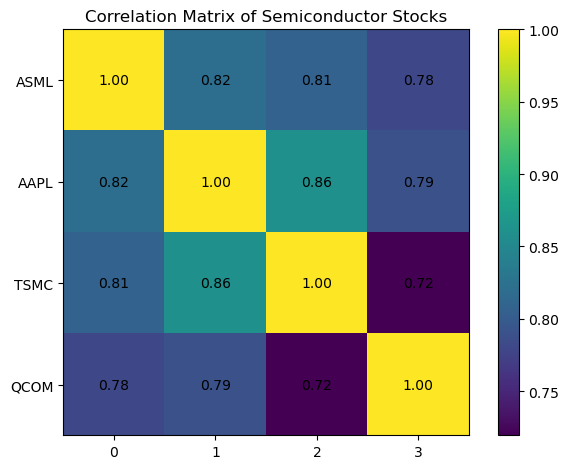

Text(0.5, 1.0, 'Correlation Matrix of Raw Metals')

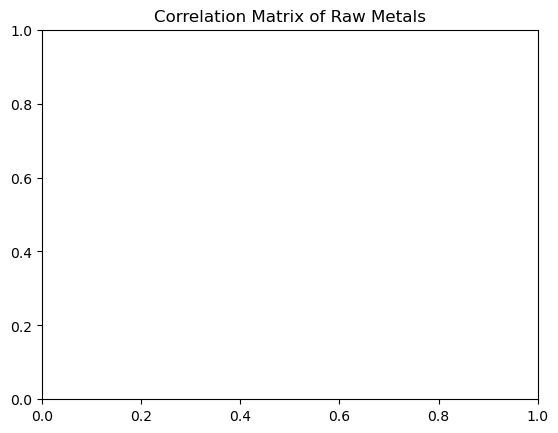

In [30]:
corr_df = pd.DataFrame(
    [
        [1.000000, 0.820968, 0.807154, 0.780001],
        [0.820968, 1.000000, 0.860488, 0.788815],
        [0.807154, 0.860488, 1.000000, 0.719413],
        [0.780001, 0.788815, 0.719413, 1.000000]
    ],
    columns=["ASML", "AAPL", "TSMC", "QCOM"],
    index=["ASML", "AAPL", "TSMC", "QCOM"]
)

plot_correlation_matrix(corr_df, "Correlation Matrix of Semiconductor Stocks")
plt.title("Correlation Matrix of Raw Metals")

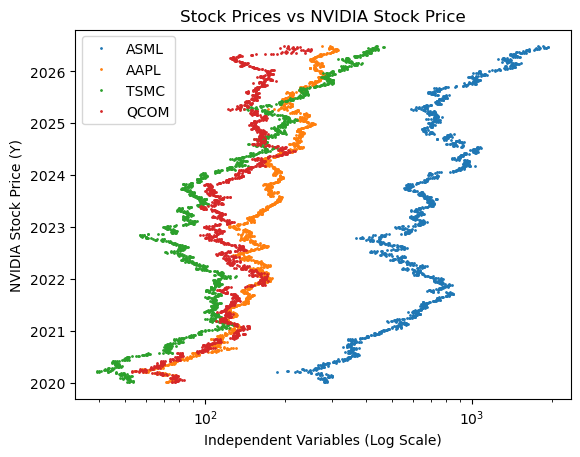

In [31]:
data1_plot = {
    "ASML": asml.history(start="2020-01-01")['Close'].shift(1),
    "AAPL": aapl.history(start="2020-01-01")['Close'].shift(1),
    # "X3": goog.history(start="2020-01-01")['Close'],
    "TSMC": tsmc.history(start="2020-01-01")['Close'].shift(1),
    "QCOM": qcom.history(start="2020-01-01")['Close'].shift(1)
}

plot_data_log(data1_plot)

### MODEL 2: yearly metal production 

Importing data

In [32]:
silver_data = pd.read_excel('../data/Silver Historical Statistics.xlsx', sheet_name="Silver")
Tin_data = pd.read_excel('../data/Tin Historical Statistics.xlsx', sheet_name="Tin")
Silicon_data = pd.read_excel('../data/Silicon Historical Statistics.xlsx', sheet_name="Silicon")
Aluminum_data = pd.read_excel('../data/Aluminum Historical Statistics.xlsx', sheet_name="Aluminum")
Rare_Earths_data = pd.read_excel('../data/Rare Earths Historical Statistics.xlsx', sheet_name="Rare earths")
Gold_data = pd.read_excel('../data/Gold Historical Statistics.xlsx', sheet_name="Gold")

filtered_silver_data = silver_data[(124-20):124]["Unnamed: 11"]
filtered_Tin_data = Tin_data[(124-20):124]["Unnamed: 11"] 
filtered_Silicon_data = Silicon_data[(102-21):101]["Unnamed: 9"] 
filtered_Aluminum_data = Aluminum_data[(124-20):124]["Unnamed: 15"] 
filtered_Rare_Earths_data = Rare_Earths_data[(124-20):124]["Unnamed: 7"] 
filtered_Gold_data = Gold_data[(124-20):124]["Unnamed: 8"]

filtered_Silicon_data

81     3500000
82     3500000
83     3720000
84     4390000
85     4900000
86     5310000
87     5650000
88     6330000
89     6510000
90     6260000
91     6930000
92     7370000
93     7450000
94     7950000
95     7900000
96     7800000
97     7700000
98     7230000
99     8890000
100    8560000
Name: Unnamed: 9, dtype: object

In [33]:
filtered_Gold_data.index = nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last().index
filtered_silver_data.index = nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last().index
filtered_Tin_data.index = nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last().index
filtered_Silicon_data.index = nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last().index
filtered_Aluminum_data.index = nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last().index
filtered_Rare_Earths_data.index = nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last().index

In [34]:
len(filtered_Aluminum_data), len(filtered_Silicon_data)

(20, 20)

In [38]:
data2 = {
    "Y": nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last(),
    # "X1": filtered_silver_data.astype(float).shift(1),
    # "X2": filtered_Tin_data.astype(float).shift(1),
    "X1": filtered_Silicon_data.astype(float).shift(1),
    # "X4": filtered_Aluminum_data.astype(float).shift(1),
    "X2": filtered_Rare_Earths_data.astype(float).shift(1),
    "X3": filtered_Gold_data.astype(float).shift(1)
}

In [36]:
p_valueTest(data2)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     30.78
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           1.18e-06
Time:                        11:31:13   Log-Likelihood:                -17.722
No. Observations:                  19   AIC:                             43.44
Df Residuals:                      15   BIC:                             47.22
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.6382      1.458     -7.981      0.0

/opt/homebrew/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=19
  res = hypotest_fun_out(*samples, **kwds)


In [39]:
Durbin_Watson_test(data2)

Durbin-Watson statistic: 2.254602815006924
rho estimate: -0.12730140750346197
z-statistic: -0.5092056300138479
p-value: 0.6106080971928642


In [40]:
Pagan_test(data2)

Lagrange multiplier statistic: 4.4344346526191085
p-value: 0.21821365681823984
f-value: 1.5222322466928777
f p-value: 0.24951093514395845


In [41]:
Whites_test(data2)

Test Statistic: 9.53352740319414
Test Statistic p-value: 0.2993029808118815
F-Statistic: 1.2588542492600285
F-Test p-value: 0.35942804655029054


In [42]:
VIF_test(data2)

  Variable        VIF
0    const  84.340112
1       X1   2.197316
2       X2   1.677211
3       X3   1.786686


In [43]:
corr_df2 = correlation_matrix(data2)

corr_df2

,X1,X2,X3
X1,1.000000,0.623875,0.653180
X2,0.623875,1.000000,0.498845
X3,0.653180,0.498845,1.000000


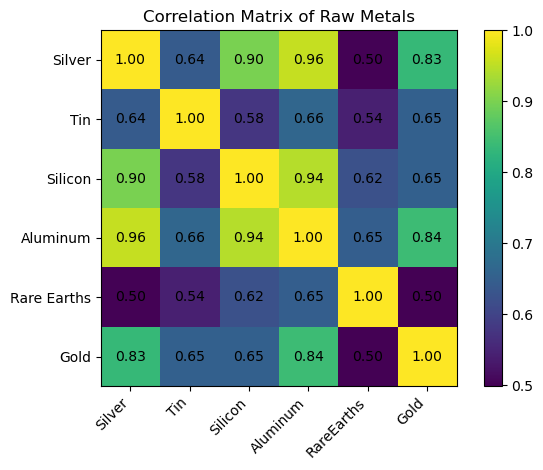

In [44]:
corr_df2 = pd.DataFrame(
    [
        [1.000000, 0.642150, 0.899768, 0.956202, 0.500906, 0.834021],
        [0.642150, 1.000000, 0.578023, 0.664324, 0.543646, 0.651947],
        [0.899768, 0.578023, 1.000000, 0.944878, 0.623875, 0.653180],
        [0.956202, 0.664324, 0.944878, 1.000000, 0.648099, 0.842747],
        [0.500906, 0.543646, 0.623875, 0.648099, 1.000000, 0.498845],
        [0.834021, 0.651947, 0.653180, 0.842747, 0.498845, 1.000000]
    ],
    columns=["Silver", "Tin", "Silicon", "Aluminum", "RareEarths", "Gold"],
    index=["Silver", "Tin", "Silicon", "Aluminum", "Rare Earths", "Gold"]
)

plot_correlation_matrix_rotate(corr_df2, "Correlation Matrix of Raw Metals")

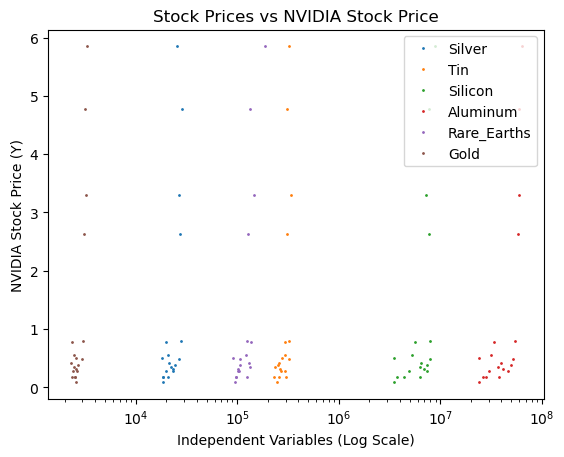

In [45]:
data2_plot = {
    "Y": nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last(),
    "Silver": filtered_silver_data.astype(float).shift(1),
    "Tin": filtered_Tin_data.astype(float).shift(1),
    "Silicon": filtered_Silicon_data.astype(float).shift(1),
    "Aluminum": filtered_Aluminum_data.astype(float).shift(1),
    "Rare_Earths": filtered_Rare_Earths_data.astype(float).shift(1),
    "Gold": filtered_Gold_data.astype(float).shift(1)
}

plot_data_log_y(data2_plot)

## MODEL 3: Daily metal prices

In [46]:
data3 = {
    "X1": copper.history(start="2020-01-01")['Close'].shift(1), 
    "X2": gold.history(start="2020-01-01")['Close'].shift(1),
    "X3": silver.history(start="2020-01-01")['Close'].shift(1),
    "X4": platinum.history(start="2020-01-01")['Close'].shift(1), 

    "Y": nvda.history(start="2020-01-01")['Close'], 
}

In [47]:
Cochrane_Orcutt_test(data3)

Estimated rho: 0.9809
Adjusted R²: 0.0458
Durbin-Watson statistic: 1.8959
rho estimate: 0.0520
z-statistic: 2.0963
p-value: 0.0361


In [48]:
for i in LRM(data3):
    print(i)

['X1', -3.2328024655102383]
['X2', 0.046461414050404604]
['X3', 6.31091685757112]
['X4', -0.17232657112320424]


In [49]:
p_valueTest(data3)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     4250.
Date:                Sat, 27 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:31:40   Log-Likelihood:                -7127.9
No. Observations:                1628   AIC:                         1.427e+04
Df Residuals:                    1623   BIC:                         1.429e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -110.8267      3.871    -28.631      0.0

In [50]:
Durbin_Watson_test(data3)

Durbin-Watson statistic: 0.03825502727256182
rho estimate: 0.980872486363719
z-statistic: 39.5280659182394
p-value: 0.0


In [51]:
Pagan_test(data3)

Lagrange multiplier statistic: 462.1611101105292
p-value: 1.0200672837863595e-98
f-value: 160.84715654418216
f p-value: 4.8298814188811525e-116


In [52]:
Whites_test(data3)

Test Statistic: 702.4721526863766
Test Statistic p-value: 7.653033508244909e-141
F-Statistic: 87.4472092232056
F-Test p-value: 3.9951720250352074e-186


In [53]:
VIF_test(data3)

  Variable        VIF
0    const  65.383973
1       X1   2.781330
2       X2  10.126795
3       X3  27.603346
4       X4  13.061796


In [54]:
correlation_matrix(data3)

,X1,X2,X3,X4
X1,1.000000,0.779831,0.789010,0.765773
X2,0.779831,1.000000,0.941066,0.869084
X3,0.789010,0.941066,1.000000,0.955938
X4,0.765773,0.869084,0.955938,1.000000


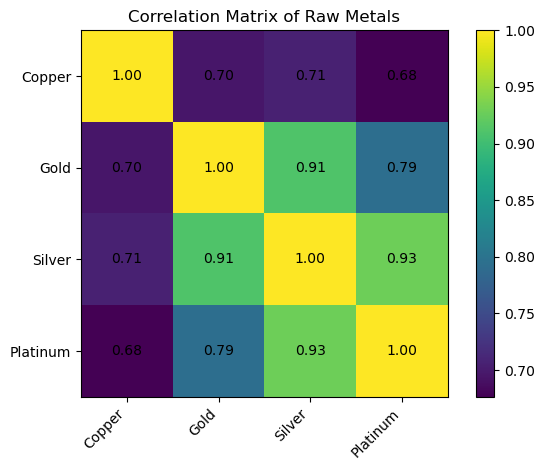

In [55]:
corr_df3 = pd.DataFrame(
    [
        [1.000000, 0.696300, 0.706531, 0.676261],
        [0.696300, 1.000000, 0.910768, 0.792748],
        [0.706531, 0.910768, 1.000000, 0.928990],
        [0.676261, 0.792748, 0.928990, 1.000000]
    ],
    columns=["Copper", "Gold", "Silver", "Platinum"],
    index=["Copper", "Gold", "Silver", "Platinum"]
)

plot_correlation_matrix_rotate(corr_df3, "Correlation Matrix of Raw Metals")

## MODEL 5: S&P 500

In [56]:
eqix = yf.Ticker("EQIX")
dlr = yf.Ticker("DLR")

data5 = {
    "Y": nvda.history(start="2020-01-01")['Close'],
    "X1": s_p.history(start="2020-01-01")['Close'].shift(1),
}

In [57]:
LRM(data5)

[['X1', 0.05884779920806672]]

In [58]:
Cochrane_Orcutt_test(data5)

Estimated rho: 0.9771
Adjusted R²: 0.0392
Durbin-Watson statistic: 1.9125
rho estimate: 0.0437
z-statistic: 1.7641
p-value: 0.0777


In [59]:
p_valueTest(data5)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.922
Model:                            OLS   Adj. R-squared:                  0.922
Method:                 Least Squares   F-statistic:                 1.914e+04
Date:                Sat, 27 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:31:41   Log-Likelihood:                -7040.7
No. Observations:                1628   AIC:                         1.409e+04
Df Residuals:                    1626   BIC:                         1.410e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -185.1919      1.883    -98.328      0.0

In [60]:
Durbin_Watson_test(data5, True)

Durbin-Watson statistic: 0.04573831693785051
rho estimate: 0.9771308415310748
z-statistic: 39.41363567033223
p-value: 0.0


In [61]:
Pagan_test(data5)

Lagrange multiplier statistic: 190.50292356031758
p-value: 2.469189598375479e-43
f-value: 215.48409300161364
f p-value: 6.6014335137547284e-46


In [62]:
Whites_test(data5)

Test Statistic: 393.2786424601299
Test Statistic p-value: 3.986831349574845e-86
F-Statistic: 258.79433853442305
F-Test p-value: 2.6951309767196565e-98


In [63]:
VIF_test(data5) #probably not needed

  Variable        VIF
0    const  17.259867
1       X1   1.000000


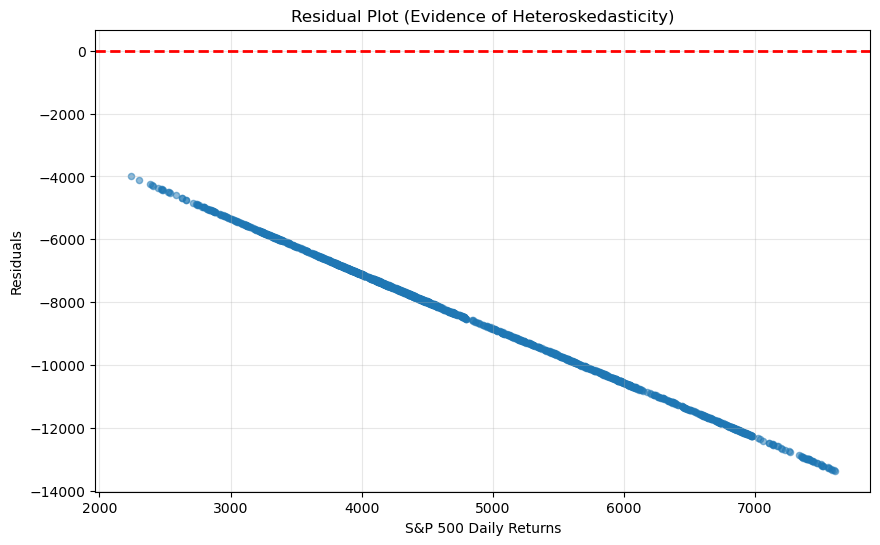

In [64]:
# Calculate residuals
data5['residuals'] = data5['Y'] - (0.0018 + 1.7839 * data5['X1'])

plt.figure(figsize=(10, 6))
plt.scatter(data5['X1'], data5['residuals'], alpha=0.5, s=20)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('S&P 500 Daily Returns')
plt.ylabel('Residuals')
plt.title('Residual Plot (Evidence of Heteroskedasticity)')
plt.grid(True, alpha=0.3)
plt.show()

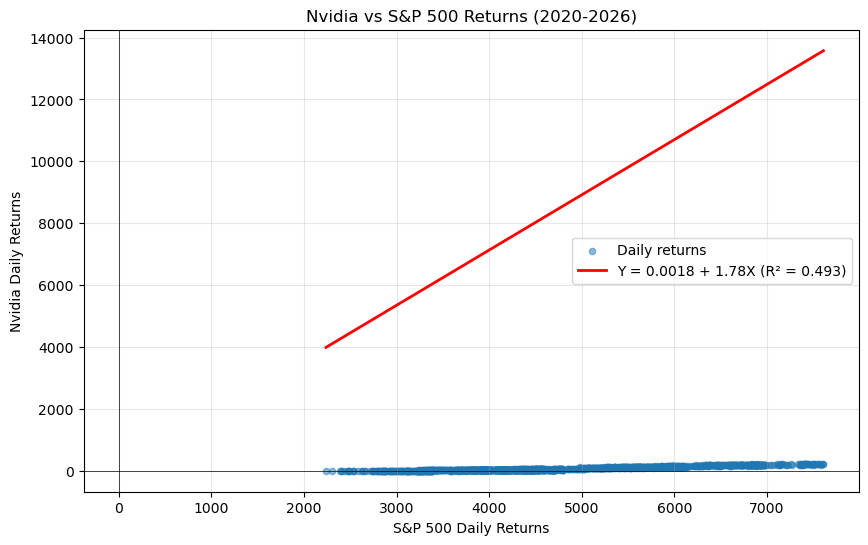

In [65]:
# Prepare data
df = pd.DataFrame(data5).dropna()

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['X1'], df['Y'], alpha=0.5, s=20, label='Daily returns')

# Add regression line
x_line = np.linspace(df['X1'].min(), df['X1'].max(), 100)
y_line = 0.0018 + 1.7839 * x_line  # Using your coefficients
plt.plot(x_line, y_line, 'r-', linewidth=2, label=f'Y = 0.0018 + 1.78X (R² = 0.493)')

plt.xlabel('S&P 500 Daily Returns')
plt.ylabel('Nvidia Daily Returns')
plt.title('Nvidia vs S&P 500 Returns (2020-2026)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
plt.show()

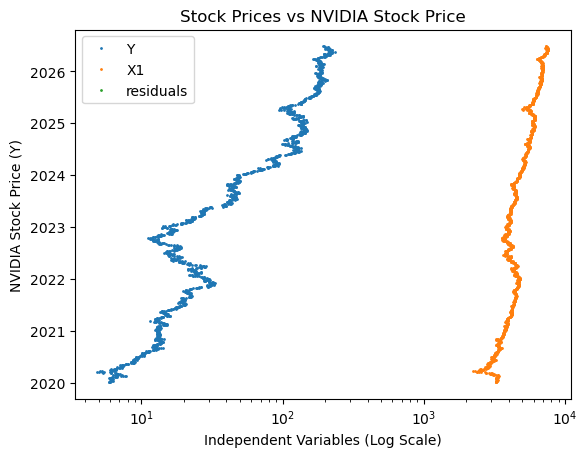

In [66]:
plot_data_log(data5)

## MODEL 6: Nasdaq

In [67]:
# nvda_hourly = nvda.history(start="2024-03-01", interval="1h")['Close']
# ndx_hourly = ndx.history(start="2024-03-01", interval="1h")['Close']

# data6 = {
#     "Y": nvda_hourly,
#     "X1": ndx_hourly.shift(1)
# }

data6 = {
    "Y": nvda.history(start="2020-01-01")['Close'],
    "X1": ndx.history(start="2020-01-01")['Close'].shift(1),
}

In [68]:
df6 = pd.DataFrame(data6).dropna()

df6

,Y,X1
Date,,
2020-01-03 00:00:00-05:00,5.868348,8872.219727
2020-01-06 00:00:00-05:00,5.892957,8793.900391
2020-01-07 00:00:00-05:00,5.964301,8848.519531
2020-01-08 00:00:00-05:00,5.975487,8846.450195
2020-01-09 00:00:00-05:00,6.041113,8912.370117
...,...,...
2026-06-22 00:00:00-04:00,208.649994,30406.189453
2026-06-23 00:00:00-04:00,200.039993,30347.080078
2026-06-24 00:00:00-04:00,199.000000,29347.269531


In [69]:
p_valueTest(data6)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                 2.056e+04
Date:                Sat, 27 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:31:42   Log-Likelihood:                -6986.7
No. Observations:                1628   AIC:                         1.398e+04
Df Residuals:                    1626   BIC:                         1.399e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -133.0292      1.467    -90.686      0.0

In [70]:
Durbin_Watson_test(data6, True)

Durbin-Watson statistic: 0.05068021618333148
rho estimate: 0.9746598919083342
z-statistic: 39.313967228757065
p-value: 0.0


In [71]:
Pagan_test(data6)

Lagrange multiplier statistic: 50.13645991297909
p-value: 1.4341732505306798e-12
f-value: 51.66599122634396
f p-value: 9.987732673425997e-13


In [72]:
Whites_test(data6)

Test Statistic: 117.79606534312813
Test Statistic p-value: 2.635781562784412e-26
F-Statistic: 63.37508524174083
F-Test p-value: 3.1421178319504266e-27


In [73]:
VIF_test(data6) # probably not needed

  Variable        VIF
0    const  11.188611
1       X1   1.000000


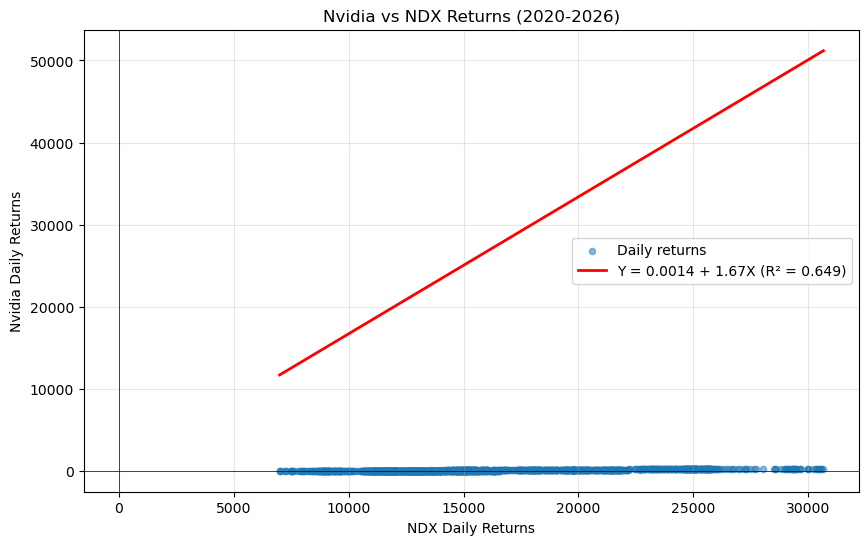

In [74]:
# Prepare data
df = pd.DataFrame(data6).dropna()

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['X1'], df['Y'], alpha=0.5, s=20, label='Daily returns')

# Add regression line
x_line = np.linspace(df['X1'].min(), df['X1'].max(), 100)
y_line = 0.0014 + 1.6695 * x_line  # Using your coefficients
plt.plot(x_line, y_line, 'r-', linewidth=2, label=f'Y = 0.0014 + 1.67X (R² = 0.649)')

plt.xlabel('NDX Daily Returns')
plt.ylabel('Nvidia Daily Returns')
plt.title('Nvidia vs NDX Returns (2020-2026)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
plt.show()

## MODEL 8: Metal ETFs 

In [75]:
data8 = {
    "X1": gold_etf.history(start="2020-01-01")['Close'].shift(1),
    "X2": silver_etf.history(start="2020-01-01")['Close'].shift(1),
    "X3": copper_etf.history(start="2020-01-01")['Close'].shift(1),
    "X4": platinum_etf.history(start="2020-01-01")['Close'].shift(1),
    "X5": uranium_etf.history(start="2020-01-01")['Close'].shift(1),

    "Y": nvda.history(start="2020-01-01")['Close'],
}

In [76]:
Cochrane_Orcutt_test(data8)

Estimated rho: 0.9724
Adjusted R²: 0.1150
Durbin-Watson statistic: 1.8680
rho estimate: 0.0660
z-statistic: 2.6584
p-value: 0.0079


In [77]:
p_valueTest(data8)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                     4764.
Date:                Sat, 27 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:31:44   Log-Likelihood:                -6873.5
No. Observations:                1628   AIC:                         1.376e+04
Df Residuals:                    1622   BIC:                         1.379e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -66.2129      4.028    -16.440      0.0

In [78]:
Durbin_Watson_test(data8)

Durbin-Watson statistic: 0.05517688666502895
rho estimate: 0.9724115566674856
z-statistic: 39.17503304762107
p-value: 0.0


In [79]:
Pagan_test(data8)

Lagrange multiplier statistic: 286.5800412391254
p-value: 7.676456285381413e-60
f-value: 69.30459381553364
f p-value: 8.24783683423666e-66


In [80]:
Whites_test(data8)

Test Statistic: 564.8218887789895
Test Statistic p-value: 7.2890282297894e-107
F-Statistic: 42.68658118936539
F-Test p-value: 6.230220679337577e-133


In [81]:
VIF_test(data8)

  Variable        VIF
0    const  96.695315
1       X1  14.924916
2       X2  28.715391
3       X3   4.103231
4       X4  12.866670
5       X5   8.937679


In [82]:
correlation_matrix(data8)

,X1,X2,X3,X4,X5
X1,1.000000,0.939766,0.797892,0.858702,0.915602
X2,0.939766,1.000000,0.793569,0.953390,0.872019
X3,0.797892,0.793569,1.000000,0.756259,0.863487
X4,0.858702,0.953390,0.756259,1.000000,0.815520
X5,0.915602,0.872019,0.863487,0.815520,1.000000


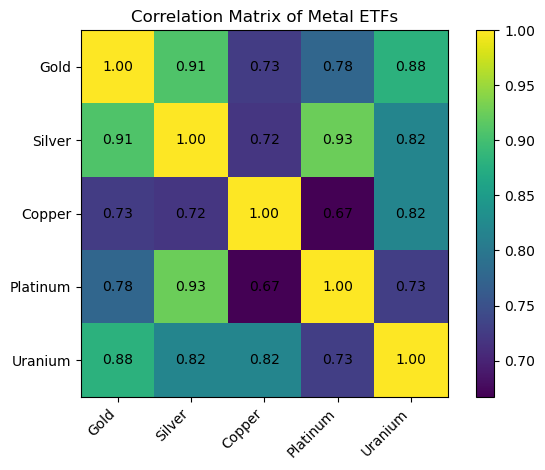

In [83]:
corr_df2 = pd.DataFrame(
    [
        [1.000000, 0.907892, 0.726390, 0.776866, 0.880414],
        [0.907892, 1.000000, 0.719532, 0.925128, 0.818067],
        [0.726390, 0.719532, 1.000000, 0.666931, 0.818781],
        [0.776866, 0.925128, 0.666931, 1.000000, 0.729022],
        [0.880414, 0.818067, 0.818781, 0.729022, 1.000000]
    ],
    columns=["Gold", "Silver", "Copper", "Platinum", "Uranium"],
    index=["Gold", "Silver", "Copper", "Platinum", "Uranium"]
)

plot_correlation_matrix_rotate(corr_df2, "Correlation Matrix of Metal ETFs")

## MODEL 9: MUDULAR NUCLEAR REACTORS.

In [84]:
data9 = {
    "X1": nuscale.history(start="2020-01-01")['Close'],
    "X2": oklo.history(start="2020-01-01")['Close'],
    "X3": ge_vernova.history(start="2020-01-01")['Close'],
    "X4": bwx.history(start="2020-01-01")['Close'],
    "X5": nano_nuclear.history(start="2020-01-01")['Close'],

    "Y": nvda.history(start="2020-01-01")['Close'],
}

In [85]:
Cochrane_Orcutt_test(data9)

Estimated rho: 0.9392
Adjusted R²: 0.3746
Durbin-Watson statistic: 1.9923
rho estimate: 0.0038
z-statistic: 0.0882
p-value: 0.9297


In [86]:
p_valueTest(data9)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.900
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     956.4
Date:                Sat, 27 Jun 2026   Prob (F-statistic):          3.10e-262
Time:                        11:31:46   Log-Likelihood:                -2031.4
No. Observations:                 535   AIC:                             4075.
Df Residuals:                     529   BIC:                             4100.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         63.1868      3.507     18.016      0.0

In [87]:
Durbin_Watson_test(data9)

Durbin-Watson statistic: 0.12138110912353635
rho estimate: 0.9393094454382318
z-statistic: 21.624527374567602
p-value: 0.0


In [88]:
Pagan_test(data9)

Lagrange multiplier statistic: 82.58670585059023
p-value: 2.412053900657386e-16
f-value: 19.313476398655126
f p-value: 1.1189344630319441e-17


In [89]:
Whites_test(data9)

Test Statistic: 166.1203778393514
Test Statistic p-value: 4.9125627712479215e-25
F-Statistic: 11.573677302814074
F-Test p-value: 1.4807773463427758e-30


In [90]:
VIF_test(data9)

  Variable        VIF
0    const  55.956630
1       X1   3.288639
2       X2   7.723492
3       X3   7.823856
4       X4  13.464331
5       X5   5.004932


In [91]:
correlation_matrix(data9)

,X1,X2,X3,X4,X5
X1,1.000000,0.596973,0.108345,0.201338,0.789247
X2,0.596973,1.000000,0.641405,0.785256,0.802082
X3,0.108345,0.641405,1.000000,0.921612,0.407508
X4,0.201338,0.785256,0.921612,1.000000,0.496278
X5,0.789247,0.802082,0.407508,0.496278,1.000000


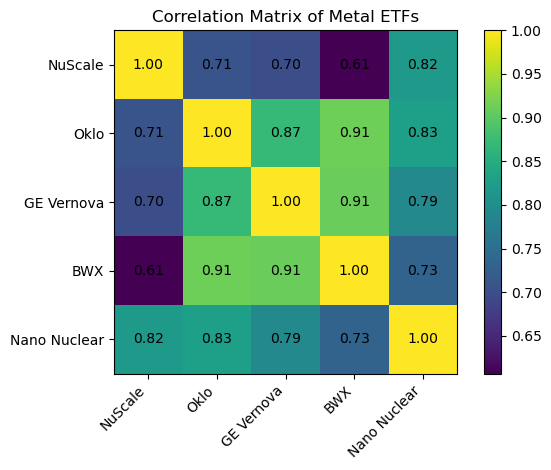

In [92]:
corr_df9 = pd.DataFrame(
    [
        [1.000000, 0.708873, 0.701035, 0.606506, 0.817787],
        [0.708873, 1.000000, 0.869783, 0.913237, 0.829280],
        [0.701035, 0.869783, 1.000000, 0.909992, 0.791180],
        [0.606506, 0.913237, 0.909992, 1.000000, 0.731993],
        [0.817787, 0.829280, 0.791180, 0.731993, 1.000000]
    ],
    columns=["NuScale", "Oklo", "GE Vernova", "BWX", "Nano Nuclear"],
    index=["NuScale", "Oklo", "GE Vernova", "BWX", "Nano Nuclear"]
)

plot_correlation_matrix_rotate(corr_df9, "Correlation Matrix of Metal ETFs")

## MODEL ULTIMATE

In [93]:
dataU = {
    "Y": nvda.history(start="2020-01-01")['Close'],
    "X1": asml.history(start="2020-01-01")['Close'],
    "X2": uranium_etf.history(start="2020-01-01")['Close'],
    "X3": ndx.history(start="2020-01-01")['Close']
}

In [94]:
Cochrane_Orcutt_test(dataU)

Estimated rho: 0.9871
Adjusted R²: 0.4632
Durbin-Watson statistic: 2.0146
rho estimate: -0.0073
z-statistic: -0.2943
p-value: 0.7685


In [95]:
p_valueTest(dataU)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.944
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                     9120.
Date:                Sat, 27 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:31:47   Log-Likelihood:                -6772.9
No. Observations:                1629   AIC:                         1.355e+04
Df Residuals:                    1625   BIC:                         1.358e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -124.4452      1.656    -75.151      0.0

In [96]:
Durbin_Watson_test(dataU)

Durbin-Watson statistic: 0.02586653934440907
rho estimate: 0.9870667303277955
z-statistic: 39.802173146388974
p-value: 0.0


In [97]:
VIF_test(dataU)

  Variable        VIF
0    const  18.624496
1       X1   5.306198
2       X2   9.020622
3       X3   8.360014


In [98]:
Pagan_test(dataU)

Lagrange multiplier statistic: 158.97801738847502
p-value: 3.045630561317128e-34
f-value: 58.57945919904467
f p-value: 5.8810227853760654e-36


In [99]:
Whites_test(dataU)

Test Statistic: 195.21339290014237
Test Statistic p-value: 3.3356146584394397e-37
F-Statistic: 24.49229206853024
F-Test p-value: 1.0724074806670379e-39


In [100]:
correlation_matrix(dataU)

,X1,X2,X3
X1,1.000000,0.889593,0.880278
X2,0.889593,1.000000,0.931442
X3,0.880278,0.931442,1.000000


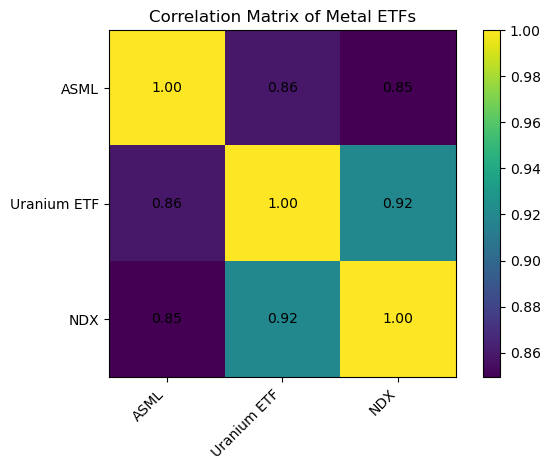

In [101]:
corr_dfU = pd.DataFrame(
    [
        [1.000000, 0.859099, 0.849275],
        [0.859099, 1.000000, 0.919765],
        [0.849275, 0.919765, 1.000000]
    ],
    columns=["ASML", "Uranium ETF", "NDX"],
    index=["ASML", "Uranium ETF", "NDX"]
)

plot_correlation_matrix_rotate(corr_dfU, "Correlation Matrix of Metal ETFs")

In [102]:
# Your data dictionary (based on your screenshot)
data = {
    'Y': nvda.history(start='2020-01-01')['Close'],
    'X1': asml.history(start='2020-01-01')['Close'],
    'X2': qcom.history(start='2020-01-01')['Close'],
    'X3': uranium_etf.history(start='2020-01-01')['Close'],
    'X4': ndx.history(start='2020-01-01')['Close']
}

df = pd.DataFrame(data)

# Prepare X and Y
Y = df['Y']
X = df[['X1', 'X2', 'X3', 'X4']]

# Add constant
X = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(Y, X)
results = model.fit()

# Get Newey-West HAC standard errors
# maxlags=5 is a good starting point for daily data
nw_results = results.get_robustcov_results(cov_type='HAC', maxlags=5)

print("=" * 80)
print("NEWEY-WEST (HAC) STANDARD ERRORS")
print("=" * 80)
print(nw_results.summary())

# You can also access individual values:
print("\nCoefficients with Newey-West Standard Errors:")
print(nw_results.params)
print("\nNewey-West P-values:")
print(nw_results.pvalues)
print("\nNewey-West Confidence Intervals:")
print(nw_results.conf_int())

NEWEY-WEST (HAC) STANDARD ERRORS
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     2691.
Date:                Sat, 27 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:31:49   Log-Likelihood:                -6713.9
No. Observations:                1629   AIC:                         1.344e+04
Df Residuals:                    1624   BIC:                         1.346e+04
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -116.79

In [103]:
# Replace QCOM with TSMC
data_tsmc = {
    'Y': nvda.history(start='2020-01-01')['Close'],
    'X1': asml.history(start='2020-01-01')['Close'],
    'X2': tsmc.history(start='2020-01-01')['Close'],  # Replace QCOM with TSMC
    'X3': uranium_etf.history(start='2020-01-01')['Close'],
    'X4': ndx.history(start='2020-01-01')['Close']
}

df_tsmc = pd.DataFrame(data_tsmc)

Y = df_tsmc['Y']
X = df_tsmc[['X1', 'X2', 'X3', 'X4']]
X = sm.add_constant(X)

# Fit with Newey-West
model = sm.OLS(Y, X)
results = model.fit()
nw_results = results.get_robustcov_results(cov_type='HAC', maxlags=8)

print(nw_results.summary())

# Check VIFs
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     2023.
Date:                Sat, 27 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:31:51   Log-Likelihood:                -6641.3
No. Observations:                1629   AIC:                         1.329e+04
Df Residuals:                    1624   BIC:                         1.332e+04
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -101.5979      7.210    -14.091      0.0